In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean as cmc
from matplotlib.colors import LogNorm
from scipy.stats import binned_statistic
import glob
import os

from cloud_filtering.training.surface_algorithm import deep_convection_mask, surface_mask_tmp

plt.style.use('../plotstyling.mplstyle')


In [39]:
# --- Load data ---
#datetime_str = "20250605023209_20250605041037"
datetime_str = "20250605023209_20250605041037"
#chip_ds = xr.open_dataset(f"../../../DataStorage/AWS/chip-aws-v0.6/chip-aws_{datetime_str}_v0.6.2.nc")
cs_ds   = xr.open_dataset(f"../../../DataStorage/AWS/l2_cloud_signal/updated_surface_algo/l2_cloud_signal_{datetime_str}.nc")

channels       = ["AWS21", "AWS31", "AWS32", "AWS33", "AWS34", "AWS35", "AWS36", "AWS44", "AWS43", "AWS42", "AWS41"]
channels_diffs = ["21-31", "31-32", "32-33", "33-34", "34-35", "35-36", "36-44", "44-43", "43-42", "42-41"]
channel_pairs  = [("AWS33", "AWS44"), ("AWS34", "AWS43"), ("AWS35", "AWS42"), ("AWS36", "AWS41")]


start, end = 1300, 1700  # interesting case
#start, end = 2300, 3200  # antarctica
#start, end = 1500, 2500

In [46]:
Ta = {ch: cs_ds.tb.sel(channel=f"AWS{ch}").values for ch in [31, 32, 33, 34, 35, 36, 41, 42, 43, 44]}
mean = cs_ds.Ta_CloudSignal_AWS33_mean.values
latitude = cs_ds.latitude.values
cond_dc = deep_convection_mask(latitude, Ta)
smask_all = surface_mask_tmp(cs_ds)  # call once on full dataset

for start in range(0, 5000, 300):
    end = start + 300
    lat_slice = cs_ds.latitude[start:end].values
    if not np.any(np.abs(lat_slice) < 30):
        continue

    nan_mask      = np.isnan(cs_ds.Ta_CloudSignal_AWS33_mean[start:end].values)
    bad_mask      = cs_ds.flag_bad_data[start:end].values != 0
    nan_surface   = nan_mask & ~bad_mask
    mean_slice    = mean[start:end]
    cond_dc_slice = cond_dc[start:end]
    smask_slice = smask_all[33][start:end] & ~bad_mask

    fig, axes = plt.subplots(1, 3, figsize=(30, 12), subplot_kw={"projection": ccrs.PlateCarree()})
    plt.subplots_adjust(wspace=0.5)

    titles = ["Mean cloud signal (AWS33) [K]", "Deep convection", "Surface mask vs DC"]
    data   = [mean_slice, mean_slice, mean_slice, mean_slice]
    cmaps  = [cmc.cm.ice_r, cmc.cm.ice_r, cmc.cm.ice_r, cmc.cm.ice_r]
    vmins  = [0, 0, 0, 0]
    vmaxs  = [100, 100, 40, 100]

    for i, (ax, title, d, cmap, vmin, vmax) in enumerate(zip(axes, titles, data, cmaps, vmins, vmaxs)):
        ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=3)
        ax.add_feature(cfeature.BORDERS,   linewidth=0.3, zorder=3)
        ax.add_feature(cfeature.LAND,  facecolor="lightgray", zorder=0)
        ax.add_feature(cfeature.OCEAN, facecolor="white",     zorder=0)
        gl = ax.gridlines(draw_labels=True, linewidth=0.2, color='gray', alpha=0.5, linestyle='--')
        gl.top_labels = gl.right_labels = False
        gl.xlabel_style = gl.ylabel_style = {'size': 16}
        ax.set_title(title, fontsize=14)

        valid = ~nan_surface

        if i == 0:
            # --- subplot 1: nan-based surface mask ---
            sc = ax.scatter(
                cs_ds.longitude[start:end].values[valid],
                cs_ds.latitude[start:end].values[valid],
                c=d[valid], s=5, vmin=vmin, vmax=vmax, ec="None", zorder=1, cmap=cmap,
            )
            if nan_surface.any():
                ax.scatter(
                    cs_ds.longitude[start:end].values[nan_surface],
                    cs_ds.latitude[start:end].values[nan_surface],
                    c="red", s=15, ec="None", label="Surface impact", zorder=2,
                )
                ax.legend(fontsize=14)
            cax = fig.add_axes([
                ax.get_position().x1 + 0.01,
                ax.get_position().y0,
                0.01,
                ax.get_position().height
            ])
            fig.colorbar(sc, cax=cax, label=title)
            ax.set_title(f"N = {len(cs_ds.longitude[start:end].values[nan_surface])}")

        elif i == 1:
            """
            # --- subplot 2: surface_mask function output ---
            sc = ax.scatter(
                cs_ds.longitude[start:end].values[valid],
                cs_ds.latitude[start:end].values[valid],
                c=d[valid], s=5, vmin=vmin, vmax=vmax, ec="None", zorder=1, cmap=cmap,
            )
            if smask_slice.any():
                ax.scatter(
                    cs_ds.longitude[start:end].values[smask_slice],
                    cs_ds.latitude[start:end].values[smask_slice],
                    c="red", s=15, ec="None", label="Surface impact (fn)", zorder=2,
                )
                ax.legend(fontsize=14)

            ax.set_title(f"N = {len(cs_ds.longitude[start:end].values[smask_slice])}")

            elif i == 2:
            """
            # --- subplot 3: deep convection ---
            sc = ax.scatter(
                cs_ds.longitude[start:end].values[valid],
                cs_ds.latitude[start:end].values[valid],
                c=d[valid], s=5, vmin=vmin, vmax=vmax, ec="None", zorder=1, cmap=cmap,
            )
            dc_valid = cond_dc_slice & valid
            if dc_valid.any():
                ax.scatter(
                    cs_ds.longitude[start:end].values[dc_valid],
                    cs_ds.latitude[start:end].values[dc_valid],
                    c="red", s=15, ec="None", label="Deep convection", zorder=2,
                )
                ax.legend(fontsize=14)

        else:
            # --- subplot 4: overlap comparison ---
            ax.scatter(
                cs_ds.longitude[start:end].values[valid],
                cs_ds.latitude[start:end].values[valid],
                c=d[valid], s=5, vmin=vmin, vmax=vmax, ec="None", zorder=1, cmap=cmap, alpha=0.0,
            )
            if nan_surface.any():
                ax.scatter(
                    cs_ds.longitude[start:end].values[nan_surface],
                    cs_ds.latitude[start:end].values[nan_surface],
                    c="red", s=15, ec="None", label="Surface impact", zorder=2,
                )
            if cond_dc_slice.any():
                ax.scatter(
                    cs_ds.longitude[start:end].values[cond_dc_slice],
                    cs_ds.latitude[start:end].values[cond_dc_slice],
                    facecolors="none", edgecolors="black", s=50, linewidths=0.5,
                    label="Deep convection", zorder=3,
                )
            n_matches = (nan_surface & cond_dc_slice).sum()
            n_surface = nan_surface.sum()
            ax.legend(fontsize=14)
            ax.set_title(f"DC matches {n_matches}/{n_surface} surface-masked points", fontsize=14)

    plt.tight_layout()
    plt.savefig(f"../figures/deep_convection/check_on_obs/updated_surface_algo/scene_{datetime_str}_{start}_{end}.png",
            dpi=200, bbox_inches="tight", facecolor="white")
    plt.close()

/tmp/ipykernel_16955/1471003374.py:124: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_16955/1471003374.py:124: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_16955/1471003374.py:124: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_16955/1471003374.py:124: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_16955/1471003374.py:124: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_16955/1471003374.py:124: UserWarning: This figure includes Axes that are not compatible with tight_layout, so resul

In [51]:
start, end = 3300, 3600
nan_mask     = np.isnan(cs_ds.Ta_CloudSignal_AWS33_mean[start:end].values)
bad_mask     = cs_ds.flag_bad_data[start:end].values != 0
surface_mask = nan_mask & ~bad_mask

scan_idx, fov_idx = np.where(surface_mask)
print(f"Surface masked points ({surface_mask.sum()} total):")
for s, f in zip(scan_idx, fov_idx):
    lat = cs_ds.latitude[start:end].values[s, f]
    lon = cs_ds.longitude[start:end].values[s, f]
    print(f"  scan={s + start}, fov={f}, lat={lat:.2f}, lon={lon:.2f}")

Surface masked points (1191 total):
  scan=3323, fov=42, lat=-37.44, lon=-71.12
  scan=3327, fov=43, lat=-37.14, lon=-71.11
  scan=3328, fov=43, lat=-37.06, lon=-71.12
  scan=3330, fov=50, lat=-36.82, lon=-70.55
  scan=3330, fov=51, lat=-36.81, lon=-70.46
  scan=3330, fov=52, lat=-36.80, lon=-70.37
  scan=3330, fov=53, lat=-36.78, lon=-70.28
  scan=3331, fov=50, lat=-36.75, lon=-70.57
  scan=3331, fov=51, lat=-36.74, lon=-70.48
  scan=3331, fov=52, lat=-36.72, lon=-70.39
  scan=3331, fov=53, lat=-36.71, lon=-70.30
  scan=3332, fov=50, lat=-36.68, lon=-70.58
  scan=3332, fov=51, lat=-36.66, lon=-70.49
  scan=3332, fov=52, lat=-36.65, lon=-70.40
  scan=3332, fov=53, lat=-36.63, lon=-70.31
  scan=3333, fov=46, lat=-36.66, lon=-70.96
  scan=3333, fov=47, lat=-36.65, lon=-70.87
  scan=3333, fov=48, lat=-36.63, lon=-70.78
  scan=3333, fov=50, lat=-36.60, lon=-70.60
  scan=3333, fov=51, lat=-36.59, lon=-70.51
  scan=3333, fov=52, lat=-36.58, lon=-70.43
  scan=3333, fov=53, lat=-36.56, lon=-70

In [52]:
dc_mask = cond_dc[start:end]
dc_idx_scan, dc_idx_fov = np.where(dc_mask)
print(f"Deep convection points ({dc_mask.sum()} total):")
for s, f in zip(dc_idx_scan, dc_idx_fov):
    lat = cs_ds.latitude[start:end].values[s, f]
    lon = cs_ds.longitude[start:end].values[s, f]
    print(f"  scan={s + start}, fov={f}, lat={lat:.2f}, lon={lon:.2f}")

Deep convection points (0 total):


Surface masked scans at fov=66:
  scan=3358, cond_dc=False
  scan=3359, cond_dc=False
  scan=3360, cond_dc=False
  scan=3361, cond_dc=False
  scan=3362, cond_dc=False
  scan=3363, cond_dc=False
  scan=3364, cond_dc=False
  scan=3365, cond_dc=False
  scan=3366, cond_dc=False
  scan=3367, cond_dc=False
  scan=3368, cond_dc=False
  scan=3369, cond_dc=False
  scan=3370, cond_dc=False
  scan=3371, cond_dc=False
  scan=3372, cond_dc=False
  scan=3373, cond_dc=False
  scan=3374, cond_dc=False
  scan=3375, cond_dc=False
  scan=3376, cond_dc=False
  scan=3377, cond_dc=False
  scan=3378, cond_dc=False
  scan=3379, cond_dc=False
  scan=3380, cond_dc=False
  scan=3381, cond_dc=False
  scan=3382, cond_dc=False
  scan=3383, cond_dc=False
  scan=3384, cond_dc=False
  scan=3385, cond_dc=False
  scan=3386, cond_dc=False
  scan=3387, cond_dc=False
  scan=3388, cond_dc=False
  scan=3389, cond_dc=False
  scan=3390, cond_dc=False
  scan=3391, cond_dc=False
  scan=3392, cond_dc=False
  scan=3393, cond_dc=Fa

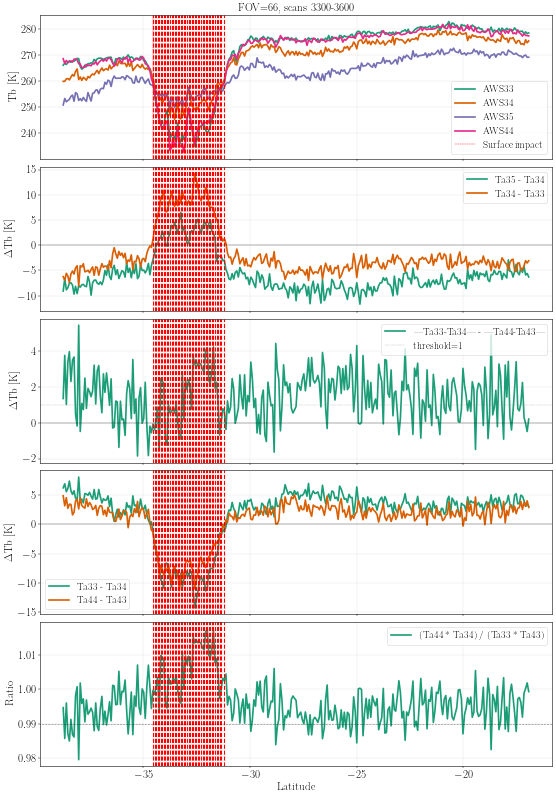

In [54]:
start, end = 3300, 3600
fov = 66
nan_mask     = np.isnan(cs_ds.Ta_CloudSignal_AWS33_mean[start:end].values)
bad_mask     = cs_ds.flag_bad_data[start:end].values != 0
surface_mask = nan_mask & ~bad_mask
scan_idx, fov_idx = np.where(surface_mask)
surface_scans = scan_idx[fov_idx == fov] + start
dc_scans      = np.where(cond_dc[start:end, fov])[0] + start
surface_lats  = cs_ds.latitude[surface_scans, fov].values if len(surface_scans) > 0 else []
dc_lats       = cs_ds.latitude[dc_scans, fov].values      if len(dc_scans) > 0      else []

print(f"Surface masked scans at fov={fov}:")
for s in surface_scans:
    print(f"  scan={s}, cond_dc={cond_dc[s, fov]}")
print(f"DC scans at fov={fov}: {dc_scans}")

lats     = cs_ds.latitude[start:end, fov].values
ta33     = Ta[33][start:end, fov]
ta34     = Ta[34][start:end, fov]
ta35     = Ta[35][start:end, fov]
ta44     = Ta[44][start:end, fov]
ta43     = Ta[43][start:end, fov]
abs_diff = np.abs(ta33 - ta34) - np.abs(ta44 - ta43)
ratio_33 = (ta44 * ta34) / (ta33 * ta43)

def add_vlines(ax):
    for sl in surface_lats:
        ax.axvline(sl, color="red",       linestyle="--", linewidth=2)
    for dl in dc_lats:
        ax.axvline(dl, color="limegreen", linestyle="--", linewidth=2)

fig, axes = plt.subplots(5, 1, figsize=(14, 20), sharex=True)

ax = axes[0]
ax.plot(lats, ta33, label="AWS33")
ax.plot(lats, ta34, label="AWS34")
ax.plot(lats, ta35, label="AWS35")
ax.plot(lats, ta44, label="AWS44")
add_vlines(ax)
if len(surface_lats) > 0:
    ax.axvline(surface_lats[0], color="red",       linestyle="--", linewidth=0.8, label="Surface impact")
if len(dc_lats) > 0:
    ax.axvline(dc_lats[0],      color="limegreen", linestyle="--", linewidth=0.8, label="Deep convection")
ax.set_ylabel("Tb [K]")
ax.legend()
ax.set_title(f"FOV={fov}, scans {start}-{end}")
ax.grid(alpha=0.3)
#ax.set_xlim([-5,5])

ax = axes[1]
ax.plot(lats, ta35 - ta34, label="Ta35 - Ta34")
ax.plot(lats, ta34 - ta33, label="Ta34 - Ta33")
add_vlines(ax)
ax.set_ylabel(r"$\Delta$Tb [K]")
ax.legend()
ax.grid(alpha=0.3)
ax.axhline(0, color="black", linewidth=0.5)

ax = axes[2]
ax.plot(lats, abs_diff, label="|Ta33-Ta34| - |Ta44-Ta43|")
add_vlines(ax)
ax.axhline(0, color="black", linewidth=0.5)
ax.axhline(1, color="gray", linestyle=":", linewidth=0.8, label="threshold=1")
ax.set_ylabel(r"$\Delta$Tb [K]")
ax.legend()
ax.grid(alpha=0.3)

ax = axes[3]
ax.plot(lats, ta33 - ta34, label="Ta33 - Ta34")
ax.plot(lats, ta44 - ta43, label="Ta44 - Ta43")
add_vlines(ax)
ax.axhline(0, color="black", linewidth=0.5)
ax.set_ylabel(r"$\Delta$Tb [K]")
ax.legend()
ax.grid(alpha=0.3)

ax = axes[4]
ax.plot(lats, ratio_33, label="(Ta44 * Ta34) / (Ta33 * Ta43)")
add_vlines(ax)
ax.axhline(0.99, color="k", linestyle=":", linewidth=1)
ax.set_ylabel("Ratio")
ax.set_xlabel("Latitude")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(f"../figures/deep_convection/check_on_obs/spectra/scene_{datetime_str}_{start}_{end}_fov_{fov}.png",
            dpi=200, bbox_inches="tight", facecolor="white")

In [ ]:
print(f"Surface masked scans at fov={fov}:")
for s in surface_scans:
    idx = s - start
    lat = cs_ds.latitude[s, fov].values
    lon = cs_ds.longitude[s, fov].values
    print(f"  scan={s}, lat={lat:.2f}, lon={lon:.2f}, Ta33-Ta34={ta33[idx]-ta34[idx]:.2f}, Ta44-Ta43={ta44[idx]-ta43[idx]:.2f}")

In [ ]:
print(f"Surface masked scans at fov={fov}:")
for s in surface_scans:
    idx = s - start
    print(f"  scan={s}, Ta33-Ta34={ta33[idx]-ta34[idx]:.2f}, Ta44-Ta43={ta44[idx]-ta43[idx]:.2f}")

In [ ]:
for start in range(0, 5000, 400):
    end = start + 400
    lat_slice = cs_ds.latitude[start:end].values
    print(lat_slice.shape)
    if not np.any(np.abs(lat_slice) < 30):
        continue

    nan_mask     = np.isnan(cs_ds.Ta_CloudSignal_AWS33_mean[start:end].values)
    bad_mask     = cs_ds.flag_bad_data[start:end].values != 0
    surface_mask = nan_mask & ~bad_mask

    if not surface_mask.any():
        continue

    print(f"\n--- start={start}, end={end} | {surface_mask.sum()} surface-masked points ---")

    for ch in [31, 32, 33, 34, 35, 36, 41, 42, 43, 44]:
        vals = Ta[ch][start:end][surface_mask]
        print(f"  AWS{ch}: {np.round(vals, 2)}")

    print(lat_slice[surface_mask])

    Ta_3533 = (Ta[35] - Ta[33])[start:end][surface_mask]
    Ta_3534 = (Ta[35] - Ta[34])[start:end][surface_mask]
    Ta_3433 = (Ta[34] - Ta[33])[start:end][surface_mask]
    abs_diff = (np.abs(Ta[33] - Ta[34]) - np.abs(Ta[44] - Ta[43]))[start:end][surface_mask]

    print(f"  |Ta33-Ta34| - |Ta44-Ta43|: {np.round(abs_diff, 2)}")

    print(f"  Ta35-Ta33 >= Ta35-Ta34:    {Ta_3533 >= Ta_3534}  ({np.round(Ta_3533, 2)} >= {np.round(Ta_3534, 2)})")
    print(f"  Ta35-Ta34 >= Ta34-Ta33:    {Ta_3534 >= Ta_3433}  ({np.round(Ta_3534, 2)} >= {np.round(Ta_3433, 2)})")
    print(f"  Ta34-Ta33 >= 0:            {Ta_3433 >= 0}  ({np.round(Ta_3433, 2)})")
    
    print(f"  cond_dc:                   {cond_dc[start:end][surface_mask]}")